In [3]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [4]:
!pip install catboost
!pip install xgboost

In [5]:
df = pd.read_csv('Palo Alto Networks.csv')

In [6]:
# Binary : Gender , OverTime 

df['Gender']=df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df['OverTime']=df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

In [7]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,1,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,1,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,1,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,1,...,3,4,0,17,3,2,9,6,0,8


In [8]:
# Onehot Encoding : BusinessTravel,Department,EducationField,JobRole,MaritalStatus

df=df.join(pd.get_dummies(df['BusinessTravel'])).drop('BusinessTravel',axis=1)
df=df.join(pd.get_dummies(df['Department'] , prefix='Department')).drop('Department',axis=1)
df=df.join(pd.get_dummies(df['EducationField'] , prefix='Education')).drop('EducationField',axis=1)
df=df.join(pd.get_dummies(df['JobRole'])).drop('JobRole',axis=1)
df=df.join(pd.get_dummies(df['MaritalStatus'])).drop('MaritalStatus',axis=1)

In [9]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative,Divorced,Married,Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,True,False,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,True,False,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,True,False,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,True,False,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,4,1,42,2,3,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2,1,87,4,2,...,False,False,True,False,False,False,False,False,True,False
1468,49,0,1023,2,3,4,1,63,2,2,...,False,False,False,False,False,True,False,False,True,False


In [10]:
df = df.map(lambda x: 1 if x is True else 0 if x is False else x)

In [11]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative,Divorced,Married,Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,1,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,1,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,1,63,2,2,...,0,0,0,0,0,1,0,0,1,0


In [12]:
pd.options.display.max_columns = 500

df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Non-Travel,Travel_Frequently,Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Human Resources,Education_Life Sciences,Education_Marketing,Education_Medical,Education_Other,Education_Technical Degree,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative,Divorced,Married,Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,4,2571,12290,4,0,17,3,3,1,17,3,3,5,2,0,3,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,1,42,2,3,1,9991,21457,4,0,15,3,1,1,9,5,3,7,7,1,7,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,1,87,4,2,2,6142,5174,1,1,20,4,2,1,6,0,3,6,2,0,3,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,1,63,2,2,2,5390,13243,2,0,14,3,4,0,17,3,2,9,6,0,8,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0


In [13]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

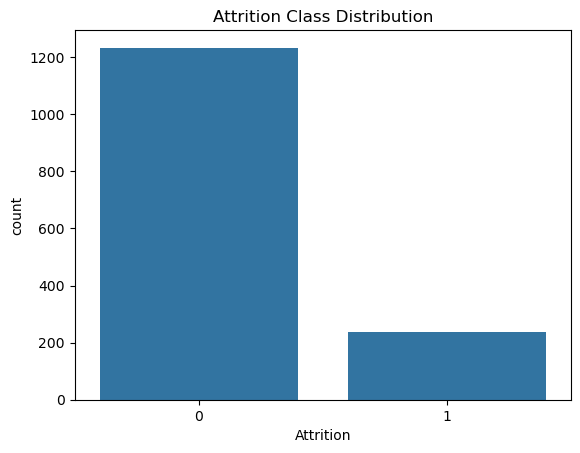

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title("Attrition Class Distribution")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def handle_imbalance(X, y):

    # Step 1: Train-Test Split (with stratification)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    print("Before SMOTE:")
    print(y_train.value_counts())

    # Step 2: Apply SMOTE ONLY on training data
    smote = SMOTE(random_state=42)

    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    print("\nAfter SMOTE:")
    print(y_train_resampled.value_counts())

    return X_train_resampled, X_test, y_train_resampled, y_test

In [16]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = handle_imbalance(X, y)

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def handle_imbalance(X, y):

    # 🔹 Full dataset distribution
    print("📊 Full Dataset Distribution:")
    print(y.value_counts())

    # 🔹 Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    print("\n📊 Train Set Before SMOTE:")
    print(y_train.value_counts())

    print("\n📊 Test Set (Unchanged):")
    print(y_test.value_counts())

    # 🔹 Apply SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    print("\n📊 Train Set After SMOTE:")
    print(y_train_resampled.value_counts())

    return X_train_resampled, X_test, y_train_resampled, y_test


# 🔥 Main Execution
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = handle_imbalance(X, y)

📊 Full Dataset Distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

📊 Train Set Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

📊 Test Set (Unchanged):
Attrition
0    247
1     47
Name: count, dtype: int64

📊 Train Set After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Income-to-experience ratio
df['IncomePerYearExp'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# Promotion delay
df['PromotionDelay'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']

# Engagement composite (normalize 1–5 scales)
df['EngagementScore'] = (df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction']) / 3

# Workload stress flag
df['WorkloadStress'] = ((df['OverTime'] == 1) & (df['WorkLifeBalance'] <= 2)).astype(int)

df['HighPerf_NoPromo'] = np.where(
    (df['PerformanceRating'] >= 4) & (df['YearsSinceLastPromotion'] > 3),
    1, 0
)


In [21]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Non-Travel,Travel_Frequently,Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Human Resources,Education_Life Sciences,Education_Marketing,Education_Medical,Education_Other,Education_Technical Degree,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative,Divorced,Married,Single,IncomePerYearExp,PromotionDelay,EngagementScore,WorkloadStress,HighPerf_NoPromo
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,665.888889,6,2.333333,1,0
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,466.363636,9,3.000000,0,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,261.250000,0,3.000000,0,0
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,323.222222,5,3.333333,0,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,495.428571,0,2.333333,0,0


In [22]:
X = df.drop(columns=['Attrition'],axis=1)

In [23]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Non-Travel,Travel_Frequently,Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Human Resources,Education_Life Sciences,Education_Marketing,Education_Medical,Education_Other,Education_Technical Degree,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative,Divorced,Married,Single,IncomePerYearExp,PromotionDelay,EngagementScore,WorkloadStress,HighPerf_NoPromo
0,41,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,665.888889,6,2.333333,1,0
1,49,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,466.363636,9,3.000000,0,0
2,37,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,261.250000,0,3.000000,0,0
3,33,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,323.222222,5,3.333333,0,0
4,27,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,495.428571,0,2.333333,0,0


In [24]:
y = df['Attrition']

In [25]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [26]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [27]:
X = preprocessor.fit_transform(X)

In [28]:
X.shape

(1470, 54)

In [29]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1176, 54), (294, 54))

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append([name, acc, prec, rec, f1, roc])

    print(f"\n{name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"ROC-AUC: {roc:.3f}")


Logistic Regression
Accuracy: 0.878
Precision: 0.548
Recall: 0.436
F1 Score: 0.486
ROC-AUC: 0.790

Decision Tree
Accuracy: 0.755
Precision: 0.133
Recall: 0.154
F1 Score: 0.143
ROC-AUC: 0.500



Random Forest
Accuracy: 0.884
Precision: 1.000
Recall: 0.128
F1 Score: 0.227
ROC-AUC: 0.758

Gradient Boosting
Accuracy: 0.878
Precision: 0.600
Recall: 0.231
F1 Score: 0.333
ROC-AUC: 0.792

KNN
Accuracy: 0.864
Precision: 0.400
Recall: 0.051
F1 Score: 0.091
ROC-AUC: 0.674

SVM
Accuracy: 0.888
Precision: 0.875
Recall: 0.179
F1 Score: 0.298
ROC-AUC: 0.803


c:\Users\nishi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:47:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.874
Precision: 0.550
Recall: 0.282
F1 Score: 0.373
ROC-AUC: 0.762


In [33]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,SVM,0.887755,0.875000,0.179487,0.297872,0.802715
3,Gradient Boosting,0.877551,0.600000,0.230769,0.333333,0.791654
0,Logistic Regression,0.877551,0.548387,0.435897,0.485714,0.790146
6,XGBoost,0.874150,0.550000,0.282051,0.372881,0.761991
2,Random Forest,0.884354,1.000000,0.128205,0.227273,0.757868
4,KNN,0.863946,0.400000,0.051282,0.090909,0.674057
1,Decision Tree,0.755102,0.133333,0.153846,0.142857,0.500452


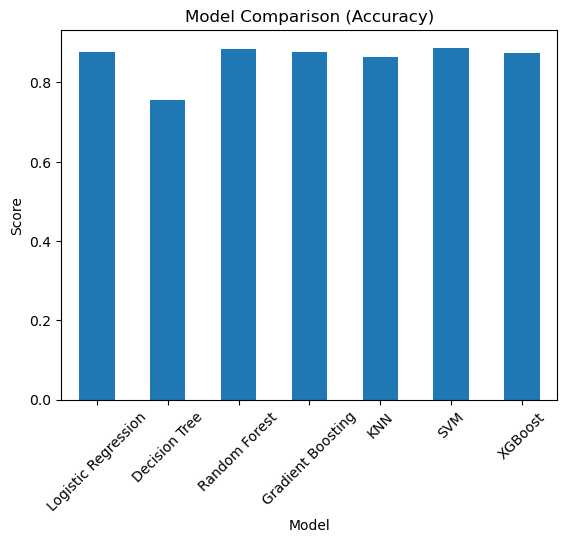

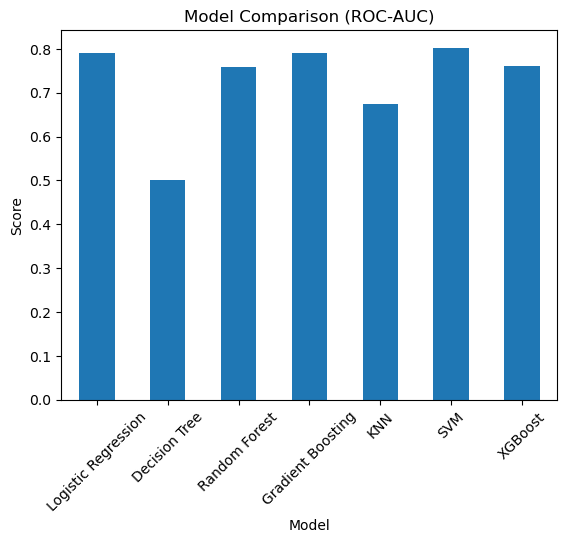

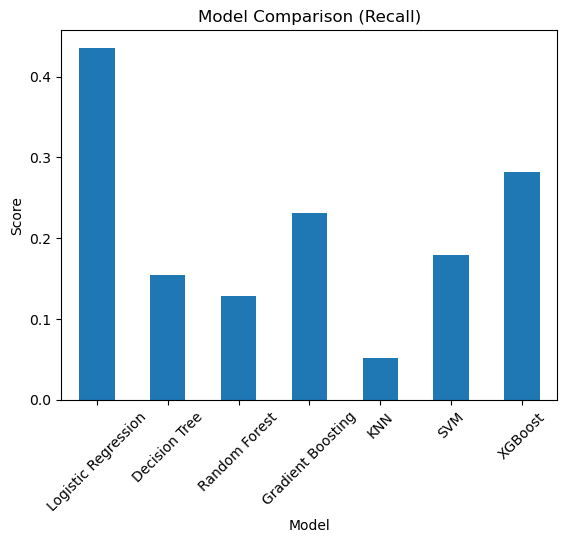

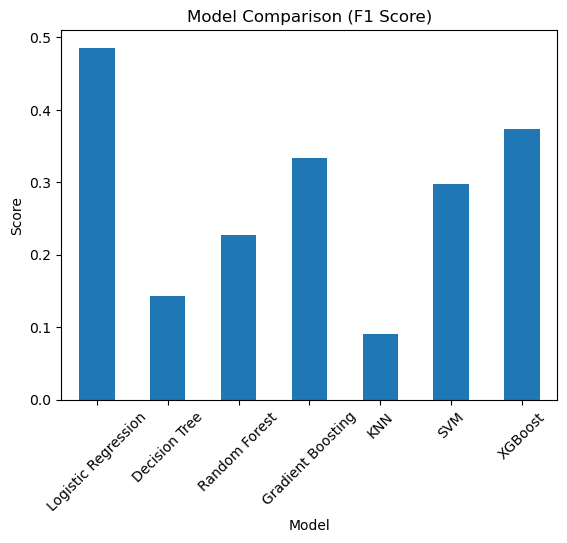

In [34]:
import matplotlib.pyplot as plt

results_df.set_index("Model")["Accuracy"].plot(kind='bar')
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

results_df.set_index("Model")["ROC-AUC"].plot(kind='bar')
plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

results_df.set_index("Model")["Recall"].plot(kind='bar')
plt.title("Model Comparison (Recall)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

results_df.set_index("Model")["F1 Score"].plot(kind='bar')
plt.title("Model Comparison (F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict, and return a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred      = model.predict(X_te)
    y_proba     = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred),    4),
        'F1-Score' : round(f1_score(y_te, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba),  4),
    }

    print(f'\n{"─"*50}')
    print(f'  {name}')
    print(f'{"─"*50}')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<12}: {v}')
    print(classification_report(y_te, y_pred, target_names=['No Attrition', 'Attrition']))

    return model, metrics, y_pred, y_proba

print('Evaluation helper defined.')

Evaluation helper defined.


In [36]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model, lr_metrics, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression', lr, X_train, y_train, X_test, y_test
)


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy    : 0.7279
  Precision   : 0.2644
  Recall      : 0.5897
  F1-Score    : 0.3651
  ROC-AUC     : 0.7706
              precision    recall  f1-score   support

No Attrition       0.92      0.75      0.83       255
   Attrition       0.26      0.59      0.37        39

    accuracy                           0.73       294
   macro avg       0.59      0.67      0.60       294
weighted avg       0.84      0.73      0.77       294



In [ ]:
"XG"== XGBClassifier(
    eval_metric='logloss',
        scale_pos_weight=scale_pos,   # dynamic — not hardcoded
        random_state=42,
        n_jobs=-1
    )

False

In [74]:
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
print(f'\nBest RF params: {rf_search.best_params_}')
print(f'Best CV ROC-AUC: {rf_search.best_score_:.4f}')

rf_model, rf_metrics, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf_search.best_estimator_, X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.8255

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Accuracy    : 0.8673
  Precision   : 0.5
  Recall      : 0.2564
  F1-Score    : 0.339
  ROC-AUC     : 0.7461
              precision    recall  f1-score   support

No Attrition       0.89      0.96      0.93       255
   Attrition       0.50      0.26      0.34        39

    accuracy                           0.87       294
   macro avg       0.70      0.61      0.63       294
weighted avg       0.84      0.87      0.85       294



In [75]:
# Compute scale_pos_weight for XGBoost's internal imbalance handling
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 7],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'subsample'         : [0.7, 0.8, 1.0],
    'colsample_bytree'  : [0.7, 0.8, 1.0],
    'reg_alpha'         : [0, 0.1, 0.5],
    'reg_lambda'        : [1, 1.5, 2],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)
print(f'\nBest XGB params: {xgb_search.best_params_}')
print(f'Best CV ROC-AUC: {xgb_search.best_score_:.4f}')

xgb_model, xgb_metrics, xgb_pred, xgb_proba = evaluate_model(
    'XGBoost', xgb_search.best_estimator_, X_train, y_train, X_test, y_test
)

scale_pos_weight: 4.94
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\nishi\Downloads\Employee_Attrition_Prediction\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [22:37:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best XGB params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.8279

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  Accuracy    : 0.8333
  Precision   : 0.3958
  Recall      : 0.4872
  F1-Score    : 0.4368
  ROC-AUC     : 0.7818
              precision    recall  f1-score   support

No Attrition       0.92      0.89      0.90       255
   Attrition       0.40      0.49      0.44        39

    accuracy                           0.83       294
   macro avg       0.66      0.69      0.67       294
weighted avg       0.85      0.83      0.84       294



In [77]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp310-cp310-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]



In [78]:
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
results_df = results_df.set_index('Model')

print('\n===== MODEL COMPARISON =====')
print(results_df.to_string())

# Highlight best value per metric
results_df.style.highlight_max(axis=0, color='#d4edda')


===== MODEL COMPARISON =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7279     0.2644  0.5897    0.3651   0.7706
Random Forest          0.8673     0.5000  0.2564    0.3390   0.7461
XGBoost                0.8333     0.3958  0.4872    0.4368   0.7818


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.727900,0.264400,0.589700,0.365100,0.770600
Random Forest,0.867300,0.500000,0.256400,0.339000,0.746100
XGBoost,0.833300,0.395800,0.487200,0.436800,0.781800


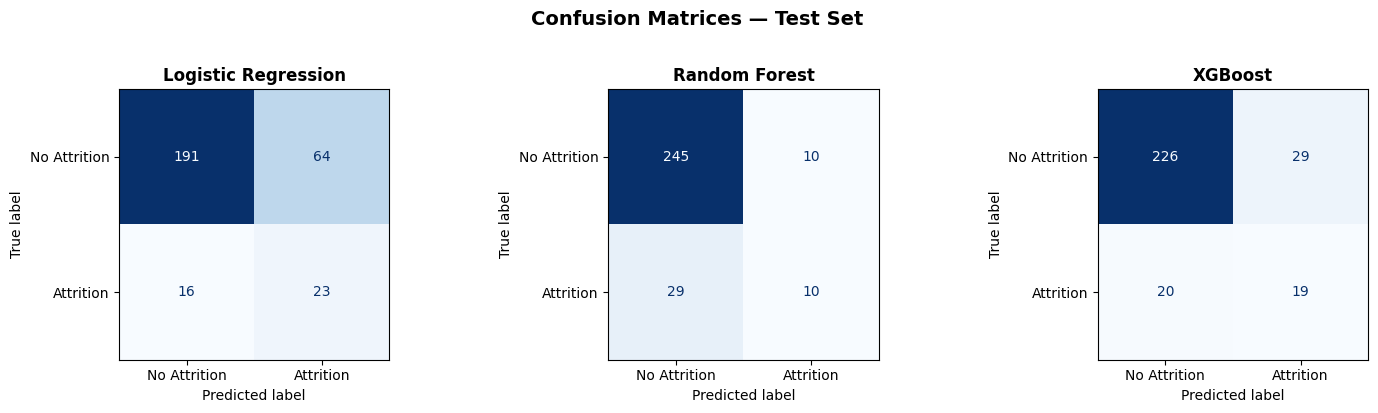

Saved: plots/confusion_matrices.png


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/confusion_matrices.png')

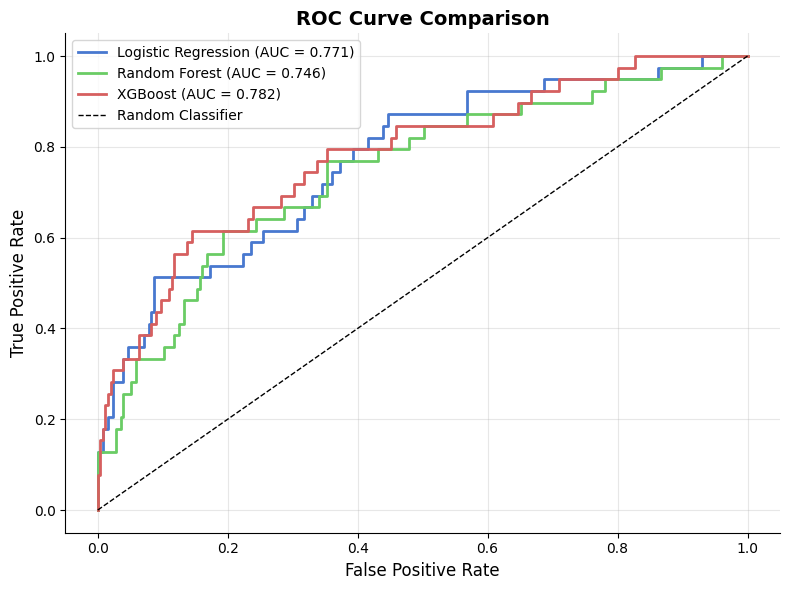

Saved: plots/roc_curves.png


In [80]:
fig, ax = plt.subplots(figsize=(8, 6))

models_proba = [
    ('Logistic Regression', lr_proba,  lr_metrics['ROC-AUC']),
    ('Random Forest',       rf_proba,  rf_metrics['ROC-AUC']),
    ('XGBoost',             xgb_proba, xgb_metrics['ROC-AUC']),
]

colors = ['#4878CF', '#6ACC65', '#D65F5F']

for (name, proba, auc), color in zip(models_proba, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('plots/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/roc_curves.png')

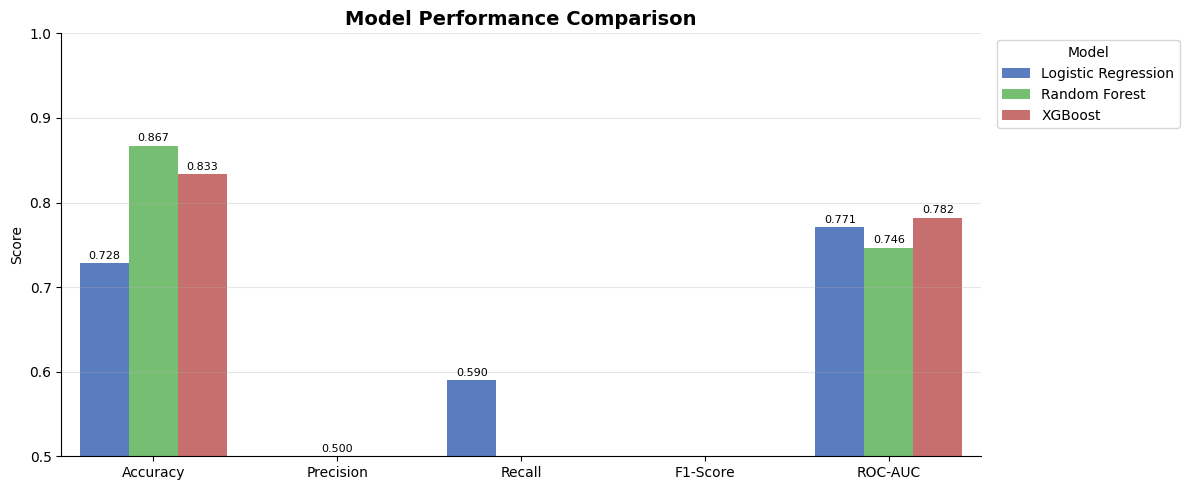

Saved: plots/model_comparison.png


In [81]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_df, x='Metric', y='Score', hue='Model',
    palette=['#4878CF', '#6ACC65', '#D65F5F'], ax=ax
)

ax.set_ylim(0.5, 1.0)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
sns.despine()

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('plots/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: plots/model_comparison.png')

In [83]:
# Pick best model by ROC-AUC
best_row = results_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_row}')

model_map = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}

best_model      = model_map[best_row]
best_model_proba = {
    'Logistic Regression': lr_proba,
    'Random Forest'      : rf_proba,
    'XGBoost'            : xgb_proba,
}[best_row]

joblib.dump(best_model, 'artifacts/best_model.pkl')
joblib.dump(results_df, 'artifacts/results_df.pkl')
np.save('artifacts/best_proba.npy', best_model_proba)

print('Saved: artifacts/best_model.pkl')
print('Saved: artifacts/results_df.pkl')
print('Saved: artifacts/best_proba.npy')
print(f'\nFinal metrics of best model ({best_row}):')
print(results_df.loc[best_row])

Best model by ROC-AUC: XGBoost
Saved: artifacts/best_model.pkl
Saved: artifacts/results_df.pkl
Saved: artifacts/best_proba.npy

Final metrics of best model (XGBoost):
Accuracy     0.8333
Precision    0.3958
Recall       0.4872
F1-Score     0.4368
ROC-AUC      0.7818
Name: XGBoost, dtype: float64
